In [1]:
import mg5qs_imports as qs
from pathlib import Path
import os

### Using mg5qs; the basics

This example demonstrates the simplest intended code pattern to be used with mg5qs; subsequent examples will expand on alturnative use cases and functionality.

This example includes:
- loading a MadGraph model
- calling MadGraph and Pythia
- storing and loading results
- calculating custom statistics (pT from px and py)
- plotting results using standard libraries



### Produce MadGraph **framework**

Initally, MadGraph requires a proc_card, containing process parameters, that can be used for a set of runs. For this set, MadGraph creates output directories and default cards (referded to here as a **framework**). More details on other types of cards soon. 

The edit_card utility displays any of MadGraph's cards. Here is a proc_card.

In [ ]:
INPUT_PATH = Path.cwd()/'input' # madgraph cards
qs.edit_card(INPUT_PATH, card_name='proc_card.dat') # don't make any changes just yet

Call MadGraph to produce an output *framework*; a directory structure in which it stores cards (run perameters, as text files), results (once generated), and other information. mg5qs stores these frameworks in the output directory.

In [3]:
# call MadGraph to generate framework
output_name, FRAMEWORK_PATH = qs.run_MG5(INPUT_PATH, proc_card_name='proc_card.dat')

starting process...
done


Now that the framework exists, its cards directory is populated with defult cards. For a non-trivial simulation, these will need to be chaged. This is also facilated with edit_card. 

Specifically: run_card contains high-level configuration setttings; param_card contains specific physical parameters. 

For now, look through the run_card (below) but refrain from making any changes.

In [ ]:
qs.edit_card(FRAMEWORK_PATH, card_name='run_card.dat')  

### Generate LHEs within framework 

Once a framework is created and cards are set up, it's time to call MadGraph to generate .lhe files. .lhe files contain the hardest subprocess, and will be used as input for Pythia momentarily.

We will also instantiate a ParamCard object, based off the param_card. This is a required argument of generate_LHE (this will seem better motavated in further examples). 

In [5]:
card = qs.ParamCard(FRAMEWORK_PATH)
qs.generate_LHE(card, FRAMEWORK_PATH)

We can confirm that we have created a single .lhe file with the get_LHEs utility. 

In [6]:
LHEs = qs.get_LHEs(FRAMEWORK_PATH)
LHEs

[PosixPath('/home/leo/output/EXAMPLE/Events/run_01/unweighted_events.lhe')]

### Shower LHEs 

Now, Pythia performs the remaining hadronization and parton showering. Its native return type is a .hepmc file. However, mg5qs intercepts the Pythia showering at run time and returns data in a python-friendly format (pandas dataframes). 

Since LHEs are independed from one another, the showering process can be carried out in parallel. Not applicable here, since we only have a single LHE file. 

In [7]:
e_id = 11
tau_id = 15
qs.pythia_parallel([e_id, tau_id], FRAMEWORK_PATH, 'EXAMPLE', topics='P_mu', size=100000)

showering: /home/leo/output/EXAMPLE/Events/run_01/unweighted_events.lhe 

finished showering 1 LHE files


### Load data

Output of pythia_parallel is automatically written to a .pkl (pickle) file, a bianry file native to python. These results are stored in a subdirectory adjcent to this notbook with a name coresponding to the third required argument. For this reason, we must first unpickle the data to load it into memory. 

The advantages of this approach will be further explored in the second and third examples. 

In [8]:
param, df = qs.unpickle('EXAMPLE') #load parameters and results 

In [9]:
param # contains all physical parameters

Abstract of Parameter Card
  /home/leo/output/EXAMPLE/Events/run_01/run_01_tag_1_banner.txt
    BLOCKS:
      MASS (17)
      SMINPUTS (3)
      YUKAWA (3)
    DECAY (17)

In [10]:
df # contains results 

,EVENT,ID,INDEX,PROCESS,STATUS,ISFINAL,ISCHARGED,px,py,pz,E
0,1,11,483,2,-23,0,1,18.551204,-7.246692,46.128020,50.243965
1,1,11,485,2,51,1,1,18.549579,-7.246058,46.123980,50.239563
2,1,11,1034,2,91,1,1,0.059502,0.010127,0.608648,0.611634
3,1,-11,1035,2,91,1,1,0.082253,0.012658,0.832518,0.836668
4,1,11,1097,2,91,1,1,-0.030075,-0.038833,-0.056280,0.074701
...,...,...,...,...,...,...,...,...,...,...,...
41059,10000,-11,1825,2,91,1,1,0.452832,-0.113116,-4.878811,4.901086
41060,10000,11,1980,2,91,1,1,-0.103140,-0.093816,6.237597,6.239155
41061,10000,-11,1981,2,91,1,1,-0.030491,-0.031096,0.895659,0.896717
41062,10000,11,1989,2,91,1,1,0.014695,-0.001070,-0.005600,0.015771


### Compute custom statistic $\space p_T=\sqrt{p_x^2+p_y^2}$

(regarding the math, don't panic)

Each row in the dataframe coresponds to a particle extracted from the showering process. The dataframe's columns are dictated by the optional, named argument **topics** in pythia_parallel. 

The most conviniant way to compute a custom statistic is to construct a new column in the dataframe, using the prexisting columns. For this simple example, we can use the x and y momenta to construct transverse momentum. 

In [11]:
import numpy as np
# operations in numpy are vectorized
df['pT'] = np.sqrt((df['px']**2)+(df['py']**2))
df # notice the new, right-most col

,EVENT,ID,INDEX,PROCESS,STATUS,ISFINAL,ISCHARGED,px,py,pz,E,pT
0,1,11,483,2,-23,0,1,18.551204,-7.246692,46.128020,50.243965,19.916369
1,1,11,485,2,51,1,1,18.549579,-7.246058,46.123980,50.239563,19.914624
2,1,11,1034,2,91,1,1,0.059502,0.010127,0.608648,0.611634,0.060357
3,1,-11,1035,2,91,1,1,0.082253,0.012658,0.832518,0.836668,0.083222
4,1,11,1097,2,91,1,1,-0.030075,-0.038833,-0.056280,0.074701,0.049117
...,...,...,...,...,...,...,...,...,...,...,...,...
41059,10000,-11,1825,2,91,1,1,0.452832,-0.113116,-4.878811,4.901086,0.466746
41060,10000,11,1980,2,91,1,1,-0.103140,-0.093816,6.237597,6.239155,0.139425
41061,10000,-11,1981,2,91,1,1,-0.030491,-0.031096,0.895659,0.896717,0.043551
41062,10000,11,1989,2,91,1,1,0.014695,-0.001070,-0.005600,0.015771,0.014734


### Plot results

We can draw the pT distribution using your prefered Python graphing library. I use matplotlib. 

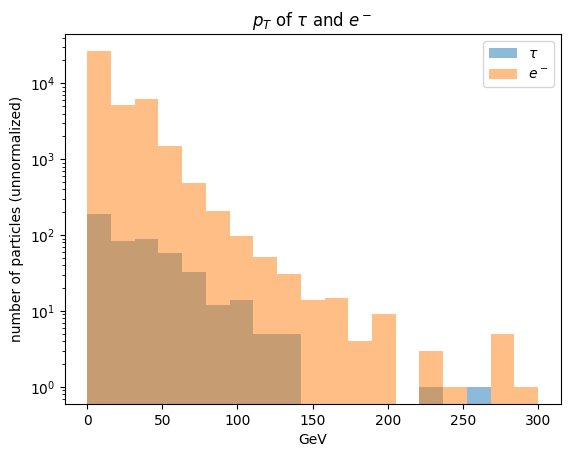

In [12]:
import matplotlib.pyplot as plt

bins = np.linspace(0, 300, 20)
plt.hist(df[np.abs(df['ID'])==tau_id]['pT'], bins=bins, label=f'$\\tau$', alpha=.5)
plt.hist(df[np.abs(df['ID'])==e_id]['pT'], bins=bins, label=f'$e^-$', alpha=.5)
plt.yscale('log')
plt.title(f'$p_T$ of $\\tau$ and $e^-$')
plt.legend()
plt.ylabel('number of particles (unnormalized)')
plt.xlabel('GeV')
plt.show()